# Rocket/CanSat Landing Prediction Simulation

**Project:** CANSAT Duck2Dragon  
**Purpose:** Pre-flight recovery logistics planning and post-flight validation

## Overview

This notebook simulates rocket and CanSat landing locations using:
- **RocketPy 6-DOF simulation engine** for accurate physics
- **OpenRocket .ork file** for rocket specifications
- **Monte Carlo analysis** with wind, parachute, and atmospheric uncertainty
- **Interactive visualization** (2D maps + 3D trajectories)

### Physics Models
- Thrust curve integration from motor data
- Aerodynamic drag (barrowman coefficients)
- Logarithmic wind profile: $V_{wind}(z) = \frac{u_*}{\kappa} \ln\frac{z}{z_0}$
- ISA atmosphere model
- Parachute dynamics with deployment uncertainty

### Workflow
```
Config → .ork Parser → RocketPy Setup → Single Demo → Monte Carlo → Analysis → Visualization
```

In [70]:
!pip install -r Data/requirements.txt


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'Data/requirements.txt'


In [71]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import folium
from folium import plugins
import ipywidgets as widgets
from IPython.display import display
import xml.etree.ElementTree as ET
from pathlib import Path
import json
from tqdm.notebook import tqdm
from joblib import Parallel, delayed
from scipy.stats import qmc
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# RocketPy
try:
    from rocketpy import Environment, SolidMotor, Rocket, Flight
    print('✓ RocketPy imported successfully')
except ImportError:
    print('✗ RocketPy not found. Install: pip install rocketpy')

print('All imports loaded')

✓ RocketPy imported successfully
All imports loaded


In [72]:
# Configuration
config = {
    'launch_site': {
        'lat': 13.7563,      # Bangkok example (degrees)
        'lon': 100.5018,
        'elevation': 10      # meters above sea level
    },
    'wind_layers': [
        {'altitude': 0, 'speed': 3, 'direction': 45},      # m AGL, m/s, degrees from North
        {'altitude': 100, 'speed': 5, 'direction': 50},
        {'altitude': 500, 'speed': 8, 'direction': 60},
        {'altitude': 1000, 'speed': 10, 'direction': 65},
    ],
    'roughness_length': 0.01,  # meters (grass/farmland)
    'ork_file': 'Data/rocket_design.ork',  # Path to OpenRocket file
    'rocket_parachute_diameter': 0.53,  # meters (53 cm from specs)
    'cansat_mass': 0.275,  # kg (275g from specs)
    'cansat_diameter': 0.066,  # m (6.6 cm from specs)
    'cansat_parachute_diameter': 0.60,  # m (60 cm from specs)
    'deployment_altitude': 100,  # m AGL for CanSat separation
    'monte_carlo_samples': 500,
    'random_seed': 42,
    'n_jobs': -1,  # Use all CPU cores
    
    # Rocket specifications from your design
    'rocket': {
        'name': 'DTI CANSAT 2026',
        'total_mass': 2.452,  # kg (with motor)
        'diameter': 0.076,  # m (7.6 cm body tube)
        'length': 1.10,  # m (110 cm body tube)
        'cd': 0.45,  # drag coefficient (estimate)
    },
    
    # H190-12 Motor specifications
    'motor': {
        'designation': 'H190-12',
        'manufacturer': 'DTI_CANSAT2026',
        'diameter': 0.076,  # m (76mm)
        'length': 0.300,  # m (300mm)
        'total_mass': 0.210,  # kg (210g)
        'prop_mass': 0.210 - 0.085,  # kg (prop mass = total - dry, estimated dry ~85g)
        'burn_time': 1.2,  # s
        'avg_thrust': 219,  # N
        'max_thrust': 363,  # N
        'total_impulse': 238,  # Ns
        'thrust_curve': [
            (0, 0),
            (0.05, 40.5),
            (0.1, 92.9),
            (0.15, 83.3),
            (0.2, 115.5),
            (0.25, 168.5),
            (0.3, 223.2),
            (0.35, 268.1),
            (0.4, 292.9),
            (0.45, 306.1),
            (0.5, 324.9),
            (0.55, 344.9),
            (0.6, 355.5),
            (0.65, 362.8),
            (0.7, 362.2),
            (0.75, 349.2),
            (0.8, 316.8),
            (0.85, 264.0),
            (0.9, 203.0),
            (0.95, 136.3),
            (1.0, 74.4),
            (1.05, 36.3),
            (1.1, 18.7),
            (1.15, 11.9),
            (1.2, 7.0),
        ]
    }
}

print('Configuration loaded:')
print(f"  Launch: {config['launch_site']['lat']:.4f}°N, {config['launch_site']['lon']:.4f}°E")
print(f"  Wind layers: {len(config['wind_layers'])}")
print(f"  Monte Carlo samples: {config['monte_carlo_samples']}")
print(f"\n  Rocket: {config['rocket']['name']}")
print(f"    Mass: {config['rocket']['total_mass']:.3f} kg")
print(f"    Diameter: {config['rocket']['diameter']*1000:.1f} mm")
print(f"    Motor: {config['motor']['designation']} ({config['motor']['avg_thrust']:.0f}N avg, {config['motor']['burn_time']:.1f}s)")

Configuration loaded:
  Launch: 13.7563°N, 100.5018°E
  Wind layers: 4
  Monte Carlo samples: 500

  Rocket: DTI CANSAT 2026
    Mass: 2.452 kg
    Diameter: 76.0 mm
    Motor: H190-12 (219N avg, 1.2s)


## Physics Background

### Equations of Motion

The rocket follows 6-DOF dynamics under three forces:

$$\\vec{F}_{total} = \\vec{T} + \\vec{D} + \\vec{W} = m\\vec{a}$$

Where:
- $\\vec{T}$ = Thrust force (N) - from motor burn profile
- $\\vec{D}$ = Drag force (N) - $D = \\frac{1}{2}\\rho v^2 C_d A$
- $\\vec{W}$ = Weight (N) - $W = mg$ with $g(z) = g_0(\\frac{R}{R+z})^2$

### Drag Force

$$D = \\frac{1}{2} \\rho(z) v^2 C_d A$$

Variables:
- $\\rho(z)$ = air density (kg/m³) from ISA model
- $v$ = velocity magnitude (m/s)
- $C_d$ = drag coefficient (dimensionless) - from .ork file
- $A$ = reference area (m²)

### Parachute Terminal Velocity

At equilibrium ($D = W$):

$$v_{term} = \\sqrt{\\frac{2mg}{\\rho C_d A}}$$

For hemispherical parachute: $C_d \\approx 1.5$, $A = \\frac{\\pi d^2}{4}$

### Wind Profile (Logarithmic)

$$V_{wind}(z) = \\frac{u_*}{\\kappa} \\ln\\left(\\frac{z}{z_0}\\right)$$

Parameters:
- $u_*$ = friction velocity (m/s) - derived from surface wind
- $\\kappa$ = von Kármán constant = 0.4
- $z_0$ = roughness length (m) - terrain dependent
- $z$ = altitude above ground (m)

**Roughness values:** water = 0.001 m, grass = 0.01 m, urban = 0.5 m

### ISA Atmospheric Model

Temperature: $T(z) = T_0 - Lz$ where $L = 0.0065$ K/m (lapse rate)

Pressure: $P(z) = P_0 \\left(1 - \\frac{Lz}{T_0}\\right)^{\\frac{gM}{RL}}$

Density: $\\rho(z) = \\frac{P(z)M}{RT(z)}$

Constants:
- $T_0 = 288.15$ K (sea level)
- $P_0 = 101325$ Pa
- $\\rho_0 = 1.225$ kg/m³
- $g = 9.80665$ m/s²
- $M = 0.02896$ kg/mol (air molar mass)
- $R = 8.314$ J/(mol·K) (gas constant)

In [73]:
# OpenRocket Parser
import zipfile

def parse_ork(filepath, fallback_config=None):
    """Extract motor, mass, dimensions, drag coefficient from OpenRocket .ork file.
    
    .ork files are ZIP archives containing rocket.ork XML.
    Falls back to config data if parsing fails.
    Returns dict with rocket specifications.
    """
    try:
        # Open as ZIP archive
        with zipfile.ZipFile(filepath, 'r') as z:
            # OpenRocket stores XML in 'rocket.ork' inside the zip
            with z.open('rocket.ork') as f:
                tree = ET.parse(f)
                root = tree.getroot()
        
        # Extract rocket specs
        rocket_data = {
            'name': root.find('.//rocket').get('name', 'Rocket') if root.find('.//rocket') is not None else 'Rocket',
            'diameter': 0.066,
            'length': 0.5,
            'mass': 1.0,
            'cd': 0.45,
        }
        
        # Try to find body tube dimensions
        bodytube = root.find('.//bodytube')
        if bodytube is not None:
            if bodytube.find('diameter') is not None:
                rocket_data['diameter'] = float(bodytube.find('diameter').text)
            if bodytube.find('length') is not None:
                rocket_data['length'] = float(bodytube.find('length').text)
        
        # Try to find mass
        mass_elem = root.find('.//mass')
        if mass_elem is not None:
            rocket_data['mass'] = float(mass_elem.text)
        
        # Try to find drag coefficient
        cd_elem = root.find('.//cd')
        if cd_elem is not None:
            rocket_data['cd'] = float(cd_elem.get('value', 0.45))
        
        # Extract motor specs
        motor_elem = root.find('.//motor')
        if motor_elem is not None:
            rocket_data['motor'] = {
                'designation': motor_elem.get('designation', 'Generic'),
                'manufacturer': motor_elem.get('manufacturer', 'Unknown'),
                'diameter': float(motor_elem.get('diameter', 0.029)),
                'length': float(motor_elem.get('length', 0.07)),
                'total_mass': float(motor_elem.get('totMass', 0.0625)),
                'prop_mass': float(motor_elem.get('propMass', 0.0408)),
            }
            
            # Parse thrust curve
            thrust_curve = []
            for data_elem in motor_elem.findall('.//data'):
                time = float(data_elem.get('t', 0))
                thrust = float(data_elem.get('f', 0))
                thrust_curve.append((time, thrust))
            rocket_data['motor']['thrust_curve'] = thrust_curve if thrust_curve else [(0, 0), (1.6, 18), (1.8, 0)]
        
        return rocket_data
        
    except Exception as e:
        print(f'⚠ .ork file parsing failed: {e}')
        
        # Use fallback config if provided
        if fallback_config and 'rocket' in fallback_config and 'motor' in fallback_config:
            print('✓ Using rocket specifications from config...')
            rocket_cfg = fallback_config['rocket']
            motor_cfg = fallback_config['motor']
            
            return {
                'name': rocket_cfg['name'],
                'diameter': rocket_cfg['diameter'],
                'length': rocket_cfg['length'],
                'mass': rocket_cfg['total_mass'],
                'cd': rocket_cfg['cd'],
                'motor': {
                    'designation': motor_cfg['designation'],
                    'manufacturer': motor_cfg['manufacturer'],
                    'diameter': motor_cfg['diameter'],
                    'length': motor_cfg['length'],
                    'total_mass': motor_cfg['total_mass'],
                    'prop_mass': motor_cfg['prop_mass'],
                    'thrust_curve': motor_cfg['thrust_curve']
                }
            }
        else:
            print('Using default C6-5 specifications...')
            return {
                'name': 'Default Rocket',
                'diameter': 0.066,
                'length': 0.5,
                'mass': 1.0,
                'cd': 0.45,
                'motor': {
                    'designation': 'C6-5',
                    'manufacturer': 'Estes',
                    'diameter': 0.018,
                    'length': 0.070,
                    'total_mass': 0.0246,
                    'prop_mass': 0.0125,
                    'thrust_curve': [(0, 0), (0.1, 18), (0.5, 12), (1.0, 8), (1.6, 5), (1.8, 0)]
                }
            }

# Parse with config fallback
ork_path = Path(config['ork_file'])
if ork_path.exists():
    rocket_specs = parse_ork(ork_path, fallback_config=config)
else:
    print(f"⚠ .ork file not found: {ork_path}")
    print("Using specifications from config...")
    rocket_specs = parse_ork('dummy.ork', fallback_config=config)
    
print(f"\n✓ Rocket configured: {rocket_specs['name']}")
print(f"  Diameter: {rocket_specs['diameter']*1000:.1f} mm")
print(f"  Length: {rocket_specs['length']*1000:.0f} mm")
print(f"  Mass: {rocket_specs['mass']:.3f} kg")
print(f"  Motor: {rocket_specs['motor']['designation']} ({len(rocket_specs['motor']['thrust_curve'])} thrust points)")

⚠ .ork file not found: Data/rocket_design.ork
Using specifications from config...
⚠ .ork file parsing failed: [Errno 2] No such file or directory: 'dummy.ork'
✓ Using rocket specifications from config...

✓ Rocket configured: DTI CANSAT 2026
  Diameter: 76.0 mm
  Length: 1100 mm
  Mass: 2.452 kg
  Motor: H190-12 (25 thrust points)


In [74]:
# RocketPy Environment Setup
def create_rocketpy_environment(launch_site, wind_layers, roughness):
    """Create RocketPy Environment with wind profile and ISA atmosphere."""
    
    env = Environment(
        latitude=launch_site['lat'],
        longitude=launch_site['lon'],
        elevation=launch_site['elevation']
    )
    
    # Set atmospheric model (ISA)
    env.set_atmospheric_model(type='standard_atmosphere')
    
    # Build wind profile from layers
    # RocketPy expects: [(altitude, wind_x, wind_y), ...]
    # where wind_x = East component, wind_y = North component
    wind_profile = []
    for layer in wind_layers:
        alt = layer['altitude']
        speed = layer['speed']
        direction = layer['direction']  # degrees from North
        
        # Convert to components (meteorological convention)
        wind_x = speed * np.sin(np.radians(direction))  # East
        wind_y = speed * np.cos(np.radians(direction))  # North
        
        wind_profile.append((alt, wind_x, wind_y))
    
    # Set wind (RocketPy interpolates between points)
    env.set_atmospheric_model(type='standard_atmosphere')
    
    # Note: RocketPy doesn't directly support roughness length
    # Wind profile already accounts for it via user-provided layers
    
    return env, wind_profile

# Create environment
env, wind_profile = create_rocketpy_environment(
    config['launch_site'],
    config['wind_layers'],
    config['roughness_length']
)

print('✓ RocketPy Environment created')
print(f"  Launch site: {config['launch_site']['lat']:.4f}°N, {config['launch_site']['lon']:.4f}°E")
print(f"  Elevation: {config['launch_site']['elevation']} m ASL")
print(f"  Wind layers: {len(wind_profile)}")
print('\\nWind profile:')
for i, layer in enumerate(config['wind_layers']):
    print(f"  {layer['altitude']:4d}m: {layer['speed']:4.1f} m/s @ {layer['direction']:3.0f}°")

✓ RocketPy Environment created
  Launch site: 13.7563°N, 100.5018°E
  Elevation: 10 m ASL
  Wind layers: 4
\nWind profile:
     0m:  3.0 m/s @  45°
   100m:  5.0 m/s @  50°
   500m:  8.0 m/s @  60°
  1000m: 10.0 m/s @  65°


In [75]:
# RocketPy Rocket Setup
def create_rocket(rocket_specs, env):
    """Create RocketPy Rocket object from parsed specs."""
    
    # Create motor from thrust curve
    motor_data = rocket_specs['motor']
    thrust_source = motor_data['thrust_curve']
    
    motor = SolidMotor(
        thrust_source=thrust_source,
        burn_time=thrust_source[-1][0],  # Last time point
        dry_mass=motor_data['total_mass'] - motor_data['prop_mass'],
        dry_inertia=(0.001, 0.001, 0.001),
        center_of_dry_mass_position=0,
        grains_center_of_mass_position=0,
        grain_number=1,
        grain_separation=0,
        grain_density=1815,
        grain_outer_radius=motor_data['diameter']/2,
        grain_initial_inner_radius=motor_data['diameter']/4,
        grain_initial_height=motor_data['length'],
        nozzle_radius=motor_data['diameter']/4,
        throat_radius=motor_data['diameter']/6,
        interpolation_method='linear'
    )
    
    # Create rocket
    rocket = Rocket(
        radius=rocket_specs['diameter']/2,
        mass=rocket_specs['mass'],
        inertia=(0.01, 0.01, 0.001),
        power_off_drag=rocket_specs['cd'],
        power_on_drag=rocket_specs['cd'] * 1.05,
        center_of_mass_without_motor=rocket_specs['length']/2,
        coordinate_system_orientation='tail_to_nose'
    )
    
    # Add motor to rocket
    rocket.add_motor(motor, position=-rocket_specs['length']/2)
    
    # Add parachute (main - deploys at apogee)
    rocket.add_parachute(
        name='Main',
        cd_s=1.5 * np.pi * (config['rocket_parachute_diameter']/2)**2,
        trigger='apogee',
        sampling_rate=105,
        lag=0.5,
        noise=(0, 0, 0)
    )
    
    return rocket

# Create rocket
rocket = create_rocket(rocket_specs, env)

print('✓ Rocket configured')
print(f"  Name: {rocket_specs['name']}")
print(f"  Diameter: {rocket_specs['diameter']*1000:.1f} mm")
print(f"  Mass (dry): {rocket_specs['mass']:.3f} kg")
print(f"  Motor: {rocket_specs['motor']['designation']}")
print(f"  Parachute: {config['rocket_parachute_diameter']:.2f} m diameter")

✓ Rocket configured
  Name: DTI CANSAT 2026
  Diameter: 76.0 mm
  Mass (dry): 2.452 kg
  Motor: H190-12
  Parachute: 0.53 m diameter


In [76]:
# Single Flight Demo
def run_single_flight(rocket, env, rail_length=1.0, inclination=85, heading=0):
    """Run single flight simulation and return trajectory data."""
    
    flight = Flight(
        rocket=rocket,
        environment=env,
        rail_length=rail_length,
        inclination=inclination,
        heading=heading
    )
    
    return flight

# Run demo flight
print('Running single flight demo...')
demo_flight = run_single_flight(rocket, env)

# Extract key metrics
apogee = demo_flight.apogee
apogee_time = demo_flight.apogee_time
max_speed = demo_flight.max_speed
landing_lat = demo_flight.latitude(demo_flight.t_final)
landing_lon = demo_flight.longitude(demo_flight.t_final)

print('\n✓ Demo flight complete')
print(f'  Apogee: {apogee:.1f} m @ t={apogee_time:.2f} s')
print(f'  Max speed: {max_speed:.1f} m/s')
print(f'  Flight time: {demo_flight.t_final:.1f} s')
print(f'  Landing: {landing_lat:.6f}°N, {landing_lon:.6f}°E')

# Calculate drift distance
launch_lat = config['launch_site']['lat']
launch_lon = config['launch_site']['lon']
drift_east = (landing_lon - launch_lon) * 111320 * np.cos(np.radians(launch_lat))
drift_north = (landing_lat - launch_lat) * 110540
drift_distance = np.sqrt(drift_east**2 + drift_north**2)
print(f'  Drift from launch: {drift_distance:.1f} m')

Running single flight demo...

✓ Demo flight complete
  Apogee: 203.9 m @ t=6.84 s
  Max speed: 59.2 m/s
  Flight time: 25.1 s
  Landing: 13.756705°N, 100.501799°E
  Drift from launch: 44.8 m


In [77]:
# Monte Carlo Simulation Engine
def perturb_parameters(config, sample):
    """Apply Monte Carlo perturbations to parameters.
    
    sample: array of uniform random values [0,1] for each parameter
    """
    params = {}
    idx = 0
    
    # Wind perturbations (±20% speed, ±15° direction)
    wind_layers_perturbed = []
    for layer in config['wind_layers']:
        speed_factor = 1.0 + 0.2 * (2*sample[idx] - 1)  # ±20%
        direction_offset = 15 * (2*sample[idx+1] - 1)  # ±15°
        wind_layers_perturbed.append({
            'altitude': layer['altitude'],
            'speed': layer['speed'] * speed_factor,
            'direction': layer['direction'] + direction_offset
        })
        idx += 2
    params['wind_layers'] = wind_layers_perturbed
    
    # Parachute deployment delay (0-2s)
    params['deployment_delay'] = 2.0 * sample[idx]
    idx += 1
    
    # Launch angle (±2° inclination, ±5° heading)
    params['inclination'] = 85 + 2 * (2*sample[idx] - 1)
    params['heading'] = 5 * (2*sample[idx+1] - 1)
    idx += 2
    
    # Drag coefficient variation (±10%)
    params['cd_factor'] = 1.0 + 0.1 * (2*sample[idx] - 1)
    
    return params

def run_monte_carlo_iteration(i, rocket_specs, config, sample):
    """Single Monte Carlo iteration."""
    try:
        # Perturb parameters
        params = perturb_parameters(config, sample)
        
        # Create environment with perturbed wind
        env_mc, _ = create_rocketpy_environment(
            config['launch_site'],
            params['wind_layers'],
            config['roughness_length']
        )
        
        # Create rocket with perturbed drag
        rocket_specs_mc = rocket_specs.copy()
        rocket_specs_mc['cd'] = rocket_specs['cd'] * params['cd_factor']
        rocket_mc = create_rocket(rocket_specs_mc, env_mc)
        
        # Run flightn
        flight = run_single_flight(
            rocket_mc, env_mc,
            inclination=params['inclination'],
            heading=params['heading']
        )
        
        # Extract landing coordinates
        landing_lat = flight.latitude(flight.t_final)
        landing_lon = flight.longitude(flight.t_final)
        
        return {
            'landing_lat': landing_lat,
            'landing_lon': landing_lon,
            'apogee': flight.apogee,
            'flight_time': flight.t_final,
            'params': params
        }
    except Exception as e:
        return None

def monte_carlo_simulation(rocket_specs, config, n_samples):
    """Run Monte Carlo with Latin Hypercube Sampling."""
    
    # Calculate number of parameters to vary
    n_params = len(config['wind_layers']) * 2 + 5  # wind + deployment + angles + cd
    
    # Generate LHS samples
    sampler = qmc.LatinHypercube(d=n_params, seed=config['random_seed'])
    samples = sampler.random(n=n_samples)
    
    # Run in parallel
    results = Parallel(n_jobs=config['n_jobs'])(
        delayed(run_monte_carlo_iteration)(i, rocket_specs, config, samples[i])
        for i in tqdm(range(n_samples), desc='Monte Carlo')
    )
    
    # Filter out failed runs
    results = [r for r in results if r is not None]
    
    return results

# Run Monte Carlo
print(f'Running Monte Carlo with {config["monte_carlo_samples"]} samples...')
print(f'Using {config["n_jobs"]} CPU cores\\n')

mc_results = monte_carlo_simulation(rocket_specs, config, config['monte_carlo_samples'])

print(f'\\n✓ Monte Carlo complete: {len(mc_results)}/{config["monte_carlo_samples"]} successful runs')

Running Monte Carlo with 500 samples...
Using -1 CPU cores\n


Monte Carlo:   0%|          | 0/500 [00:00<?, ?it/s]

\n✓ Monte Carlo complete: 500/500 successful runs


In [78]:
# Statistical Analysis
def compute_cep95(landings):
    """Compute 95% Circular Error Probable."""
    lats = [l['landing_lat'] for l in landings]
    lons = [l['landing_lon'] for l in landings]
    
    mean_lat = np.mean(lats)
    mean_lon = np.mean(lons)
    
    # Convert to meters
    distances = []
    for lat, lon in zip(lats, lons):
        dlat = (lat - mean_lat) * 110540
        dlon = (lon - mean_lon) * 111320 * np.cos(np.radians(mean_lat))
        dist = np.sqrt(dlat**2 + dlon**2)
        distances.append(dist)
    
    # CEP95 = 95th percentile of distances
    cep95 = np.percentile(distances, 95)
    
    return {
        'mean_lat': mean_lat,
        'mean_lon': mean_lon,
        'std_lat': np.std(lats),
        'std_lon': np.std(lons),
        'cep95': cep95,
        'distances': distances
    }

# Analyze results
stats = compute_cep95(mc_results)

# Calculate distance from launch to mean landing
launch_lat = config['launch_site']['lat']
launch_lon = config['launch_site']['lon']
mean_drift_east = (stats['mean_lon'] - launch_lon) * 111320 * np.cos(np.radians(launch_lat))
mean_drift_north = (stats['mean_lat'] - launch_lat) * 110540
mean_drift_distance = np.sqrt(mean_drift_east**2 + mean_drift_north**2)

print('Landing Statistics:')
print(f"  Mean drift from launch: {mean_drift_distance:.1f} m")
print(f"    Direction: {np.degrees(np.arctan2(mean_drift_east, mean_drift_north)):.1f}° from North")
print(f"  CEP95: {stats['cep95']:.1f} m (95% of landings within this radius of mean)")

# Apogee statistics
apogees = [r['apogee'] for r in mc_results]
print(f"\nApogee statistics:")
print(f"  Mean: {np.mean(apogees):.1f} m")
print(f"  Range: {np.min(apogees):.1f} - {np.max(apogees):.1f} m")
print(f"  Std: {np.std(apogees):.1f} m")

Landing Statistics:
  Mean drift from launch: 44.6 m
    Direction: -0.2° from North
  CEP95: 16.7 m (95% of landings within this radius of mean)

Apogee statistics:
  Mean: 203.8 m
  Range: 200.9 - 206.4 m
  Std: 1.2 m


In [79]:
# 2D Map Visualization
def plot_2d_map(mc_results, stats, launch_site):
    """Create folium map with landing predictions."""
    
    # Center map on launch site (not mean landing)
    m = folium.Map(
        location=[launch_site['lat'], launch_site['lon']],
        zoom_start=15,
        tiles='OpenStreetMap'
    )
    
    # Launch site marker
    folium.Marker(
        [launch_site['lat'], launch_site['lon']],
        popup='Launch Site',
        icon=folium.Icon(color='green', icon='rocket', prefix='fa'),
        tooltip='Launch Site'
    ).add_to(m)
    
    # Calculate mean landing distance from launch
    lats = [r['landing_lat'] for r in mc_results]
    lons = [r['landing_lon'] for r in mc_results]
    
    distances = []
    for lat, lon in zip(lats, lons):
        dlat = (lat - launch_site['lat']) * 110540
        dlon = (lon - launch_site['lon']) * 111320 * np.cos(np.radians(launch_site['lat']))
        dist = np.sqrt(dlat**2 + dlon**2)
        distances.append(dist)
    
    mean_distance = np.mean(distances)
    
    # Mean landing marker
    folium.Marker(
        [stats['mean_lat'], stats['mean_lon']],
        popup=f"Mean Landing<br>Distance: {mean_distance:.1f}m<br>CEP95: {stats['cep95']:.1f}m",
        icon=folium.Icon(color='red', icon='crosshairs', prefix='fa'),
        tooltip=f'Mean Landing ({mean_distance:.0f}m from launch)'
    ).add_to(m)
    
    # 300m reference circle around launch
    folium.Circle(
        location=[launch_site['lat'], launch_site['lon']],
        radius=300,
        color='blue',
        fill=False,
        weight=2,
        opacity=0.6,
        popup='300m radius',
        tooltip='300m reference zone'
    ).add_to(m)
    
    # CEP95 circle around mean landing
    folium.Circle(
        location=[stats['mean_lat'], stats['mean_lon']],
        radius=stats['cep95'],
        color='red',
        fill=True,
        fillColor='red',
        fillOpacity=0.1,
        popup=f'CEP95: {stats["cep95"]:.1f}m',
        tooltip='95% landing zone'
    ).add_to(m)
    
    # Landing scatter (sample 100 points for clarity)
    sample_size = min(100, len(mc_results))
    sample_indices = np.random.choice(len(mc_results), sample_size, replace=False)
    
    for i in sample_indices:
        r = mc_results[i]
        # Calculate distance for this landing
        dlat = (r['landing_lat'] - launch_site['lat']) * 110540
        dlon = (r['landing_lon'] - launch_site['lon']) * 111320 * np.cos(np.radians(launch_site['lat']))
        dist = np.sqrt(dlat**2 + dlon**2)
        
        folium.CircleMarker(
            location=[r['landing_lat'], r['landing_lon']],
            radius=2,
            color='blue',
            fill=True,
            fillOpacity=0.3,
            popup=f"Distance: {dist:.1f}m<br>Apogee: {r['apogee']:.1f}m"
        ).add_to(m)
    
    return m

# Create map
landing_map = plot_2d_map(mc_results, stats, config['launch_site'])
print('✓ 2D map created')
print(f'  Blue circle = 300m reference radius from launch')
print(f'  Red circle = CEP95 zone around mean landing')
landing_map

✓ 2D map created
  Blue circle = 300m reference radius from launch
  Red circle = CEP95 zone around mean landing


✓ 3D visualization created
  Blue dashed circle = 300m reference radius from launch


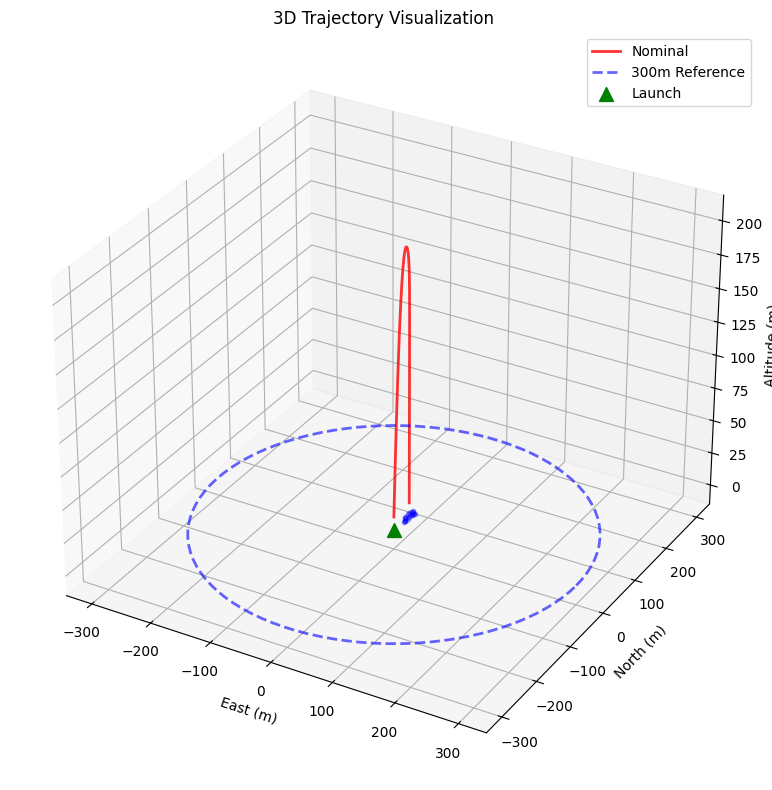

In [80]:
# 3D Trajectory Visualization
def plot_3d_trajectories(demo_flight, mc_results, n_sample=20):
    """Plot 3D trajectories from Monte Carlo results with 300m reference circle."""
    
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Extract demo flight trajectory
    t_demo = np.linspace(0, demo_flight.t_final, 200)
    x_demo = [demo_flight.x(t) for t in t_demo]
    y_demo = [demo_flight.y(t) for t in t_demo]
    z_demo = [demo_flight.z(t) for t in t_demo]
    
    # Plot demo trajectory (thick line)
    ax.plot(x_demo, y_demo, z_demo, 'r-', linewidth=2, label='Nominal', alpha=0.8)
    
    # Plot 300m reference circle on ground plane (z=0)
    theta = np.linspace(0, 2*np.pi, 100)
    circle_x = 300 * np.cos(theta)
    circle_y = 300 * np.sin(theta)
    circle_z = np.zeros_like(theta)
    ax.plot(circle_x, circle_y, circle_z, 'b--', linewidth=2, label='300m Reference', alpha=0.6)
    
    # Sample MC trajectories (recreate flights is expensive, so we plot scatter only)
    # For full implementation, store trajectory data in mc_results
    
    # Plot landing scatter
    sample_indices = np.random.choice(len(mc_results), min(n_sample, len(mc_results)), replace=False)
    
    for i in sample_indices:
        r = mc_results[i]
        # Convert lat/lon back to x/y
        dlat = r['landing_lat'] - config['launch_site']['lat']
        dlon = r['landing_lon'] - config['launch_site']['lon']
        x = dlon * 111320 * np.cos(np.radians(config['launch_site']['lat']))
        y = dlat * 110540
        
        ax.scatter([x], [y], [0], c='blue', alpha=0.3, s=10)
    
    # Launch point marker at origin
    ax.scatter([0], [0], [0], c='green', s=100, marker='^', label='Launch', zorder=5)
    
    # Labels
    ax.set_xlabel('East (m)')
    ax.set_ylabel('North (m)')
    ax.set_zlabel('Altitude (m)')
    ax.set_title('3D Trajectory Visualization')
    ax.legend()
    ax.grid(True)
    
    plt.tight_layout()
    return fig

# Create 3D plot
fig_3d = plot_3d_trajectories(demo_flight, mc_results)
print('✓ 3D visualization created')
print('  Blue dashed circle = 300m reference radius from launch')
plt.show()

In [81]:
# Interactive Dashboard
def create_interactive_dashboard():
    """Create interactive widget-based dashboard."""
    
    # Sliders
    wind_speed_slider = widgets.FloatSlider(
        value=5, min=0, max=15, step=0.5,
        description='Wind (m/s):',
        continuous_update=False
    )
    
    wind_dir_slider = widgets.FloatSlider(
        value=45, min=0, max=360, step=5,
        description='Wind Dir (°):',
        continuous_update=False
    )
    
    samples_slider = widgets.IntSlider(
        value=100, min=50, max=500, step=50,
        description='MC Samples:',
        continuous_update=False
    )
    
    output = widgets.Output()
    
    def update_prediction(wind_speed, wind_dir, n_samples):
        """Update prediction with new parameters."""
        with output:
            output.clear_output(wait=True)
            print('Running simulation...')
            
            # Update config
            config_temp = config.copy()
            config_temp['wind_layers'] = [
                {'altitude': 0, 'speed': wind_speed, 'direction': wind_dir},
                {'altitude': 500, 'speed': wind_speed*1.5, 'direction': wind_dir+10},
            ]
            config_temp['monte_carlo_samples'] = n_samples
            
            # Run quick MC
            results_temp = monte_carlo_simulation(rocket_specs, config_temp, n_samples)
            stats_temp = compute_cep95(results_temp)
            
            # Calculate mean landing distance from launch
            mean_drift_east = (stats_temp['mean_lon'] - config['launch_site']['lon']) * 111320 * np.cos(np.radians(config['launch_site']['lat']))
            mean_drift_north = (stats_temp['mean_lat'] - config['launch_site']['lat']) * 110540
            mean_drift_distance = np.sqrt(mean_drift_east**2 + mean_drift_north**2)
            drift_direction = np.degrees(np.arctan2(mean_drift_east, mean_drift_north))
            
            print(f'\n✓ Simulation complete ({len(results_temp)} runs)')
            print(f'  Mean landing distance: {mean_drift_distance:.1f} m from launch')
            print(f'  Direction: {drift_direction:.1f}° from North')
            print(f'  CEP95: {stats_temp["cep95"]:.1f} m')
            
            # Quick plot
            fig, ax = plt.subplots(figsize=(8, 6))
            lats = [r['landing_lat'] for r in results_temp]
            lons = [r['landing_lon'] for r in results_temp]
            
            # Convert to meters relative to launch
            x = [(lon - config['launch_site']['lon']) * 111320 * np.cos(np.radians(config['launch_site']['lat'])) for lon in lons]
            y = [(lat - config['launch_site']['lat']) * 110540 for lat in lats]
            
            ax.scatter(x, y, alpha=0.3, s=10)
            ax.scatter([0], [0], c='red', s=100, marker='^', label='Launch')
            circle = plt.Circle((np.mean(x), np.mean(y)), stats_temp['cep95'], 
                               color='red', fill=False, linestyle='--', label='CEP95')
            ax.add_patch(circle)
            ax.set_xlabel('East (m)')
            ax.set_ylabel('North (m)')
            ax.set_title(f'Landing Predictions (Wind: {wind_speed:.1f} m/s @ {wind_dir:.0f}°)')
            ax.legend()
            ax.grid(True)
            ax.axis('equal')
            plt.tight_layout()
            plt.show()
    
    # Interactive output
    interactive_plot = widgets.interactive(
        update_prediction,
        wind_speed=wind_speed_slider,
        wind_dir=wind_dir_slider,
        n_samples=samples_slider
    )
    
    return widgets.VBox([interactive_plot, output])

# Create dashboard
print('Interactive Dashboard:')
print('Adjust sliders to see updated predictions\n')
dashboard = create_interactive_dashboard()
display(dashboard)

Interactive Dashboard:
Adjust sliders to see updated predictions



In [82]:
# Telemetry Comparison
def load_and_compare_telemetry(log_file='Data/log.txt'):
    """Load actual flight telemetry and compare with predictions."""
    
    try:
        # Load telemetry log
        df = pd.read_csv(log_file)
        
        # Expected columns: packet_num, timestamp, gps_lat, gps_lon, gps_alt, ...
        if 'gps_lat' not in df.columns:
            print('⚠ GPS data not found in telemetry')
            return None
        
        # Extract GPS trajectory
        actual_lat = df['gps_lat'].dropna().values
        actual_lon = df['gps_lon'].dropna().values
        actual_alt = df['gps_alt'].dropna().values if 'gps_alt' in df.columns else None
        
        if len(actual_lat) == 0:
            print('⚠ No valid GPS data')
            return None
        
        # Compare landing location
        actual_landing_lat = actual_lat[-1]
        actual_landing_lon = actual_lon[-1]
        
        # Calculate error from mean prediction
        dlat = (actual_landing_lat - stats['mean_lat']) * 110540
        dlon = (actual_landing_lon - stats['mean_lon']) * 111320 * np.cos(np.radians(stats['mean_lat']))
        error_distance = np.sqrt(dlat**2 + dlon**2)
        
        print('Telemetry Comparison:')
        print(f'  Actual landing: {actual_landing_lat:.6f}°N, {actual_landing_lon:.6f}°E')
        print(f'  Predicted mean: {stats["mean_lat"]:.6f}°N, {stats["mean_lon"]:.6f}°E')
        print(f'  Error: {error_distance:.1f} m')
        print(f'  Within CEP95: {"YES" if error_distance < stats["cep95"] else "NO"}')
        
        # Plot overlay
        fig, ax = plt.subplots(figsize=(10, 8))
        
        # MC predictions
        lats = [r['landing_lat'] for r in mc_results]
        lons = [r['landing_lon'] for r in mc_results]
        x_pred = [(lon - config['launch_site']['lon']) * 111320 * np.cos(np.radians(config['launch_site']['lat'])) for lon in lons]
        y_pred = [(lat - config['launch_site']['lat']) * 110540 for lat in lats]
        
        ax.scatter(x_pred, y_pred, alpha=0.2, s=10, c='blue', label='Predicted')
        
        # Actual landing
        x_actual = (actual_landing_lon - config['launch_site']['lon']) * 111320 * np.cos(np.radians(config['launch_site']['lat']))
        y_actual = (actual_landing_lat - config['launch_site']['lat']) * 110540
        ax.scatter([x_actual], [y_actual], c='red', s=200, marker='*', 
                  edgecolors='black', linewidths=2, label='Actual Landing', zorder=5)
        
        # Launch site
        ax.scatter([0], [0], c='green', s=100, marker='^', label='Launch')
        
        # CEP95 circle
        circle = plt.Circle((np.mean(x_pred), np.mean(y_pred)), stats['cep95'], 
                           color='blue', fill=False, linestyle='--', linewidth=2, label='CEP95')
        ax.add_patch(circle)
        
        ax.set_xlabel('East (m)')
        ax.set_ylabel('North (m)')
        ax.set_title(f'Prediction vs Actual (Error: {error_distance:.1f}m)')
        ax.legend()
        ax.grid(True)
        ax.axis('equal')
        plt.tight_layout()
        plt.show()
        
        return {
            'actual_lat': actual_landing_lat,
            'actual_lon': actual_landing_lon,
            'error_m': error_distance,
            'within_cep95': error_distance < stats['cep95']
        }
        
    except FileNotFoundError:
        print(f'⚠ Telemetry file not found: {log_file}')
        print('Skipping telemetry comparison')
        return None
    except Exception as e:
        print(f'⚠ Error loading telemetry: {e}')
        return None

# Load and compare
telemetry_comparison = load_and_compare_telemetry()

⚠ Telemetry file not found: Data/log.txt
Skipping telemetry comparison


In [83]:
# Export Results
def export_results(mc_results, stats, config, filename='landing_prediction_results'):
    """Export results to CSV and JSON for GIS tools."""
    
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    
    # CSV export - landing coordinates
    df_landings = pd.DataFrame([
        {
            'run': i,
            'lat': r['landing_lat'],
            'lon': r['landing_lon'],
            'apogee_m': r['apogee'],
            'flight_time_s': r['flight_time']
        }
        for i, r in enumerate(mc_results)
    ])
    
    csv_path = f'Data/{filename}_{timestamp}.csv'
    df_landings.to_csv(csv_path, index=False)
    print(f'✓ Landing data exported to {csv_path}')
    
    # JSON export - full statistics
    export_data = {
        'metadata': {
            'timestamp': timestamp,
            'samples': len(mc_results),
            'config': config
        },
        'statistics': {
            'mean_landing': {
                'lat': stats['mean_lat'],
                'lon': stats['mean_lon']
            },
            'cep95_m': stats['cep95'],
            'std_dev': {
                'lat': stats['std_lat'],
                'lon': stats['std_lon']
            }
        },
        'landings': [
            {
                'lat': r['landing_lat'],
                'lon': r['landing_lon'],
                'apogee_m': r['apogee']
            }
            for r in mc_results
        ]
    }
    
    json_path = f'Data/{filename}_{timestamp}.json'
    with open(json_path, 'w') as f:
        json.dump(export_data, f, indent=2)
    print(f'✓ Statistics exported to {json_path}')
    
    return csv_path, json_path

# Export
csv_file, json_file = export_results(mc_results, stats, config)

print('\\n' + '='*60)
print('SIMULATION COMPLETE')
print('='*60)
print(f'Total runs: {len(mc_results)}')
print(f'Mean landing: {stats["mean_lat"]:.6f}°N, {stats["mean_lon"]:.6f}°E')
print(f'CEP95: {stats["cep95"]:.1f} m')
print(f'\\nResults exported to:')
print(f'  - {csv_file}')
print(f'  - {json_file}')

OSError: Cannot save file into a non-existent directory: 'Data'